# SaaS Pulse — Exploratory Data Analysis

**Dataset:** IBM Telco Customer Churn (7,043 customers)  
**Goal:** Understand churn drivers before modeling. Every chart here maps to a feature engineering or modeling decision downstream.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, "../src")
from features import ChurnFeatureEngineer, get_target

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
PURPLE, AMBER, TEAL = "#6366F1", "#F59E0B", "#14B8A6"

df = pd.read_csv("../data/telco_churn_raw.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn_bin"] = (df["Churn"] == "Yes").astype(int)
print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn_bin'].mean():.1%}")
df.head(3)

Shape: (7043, 22)
Churn rate: 30.3%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin
0,5230-PXXBM,Male,0,No,No,66,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,89.06,5980.66,No,0
1,9349-CLNQN,Female,1,No,No,24,Yes,No,Fiber optic,No,...,No,No,No,Two year,Yes,Electronic check,85.55,2046.07,No,0
2,9638-TGEVY,Male,0,No,No,60,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Bank transfer (automatic),22.61,1351.13,No,0


## 1. Churn Distribution & Tenure

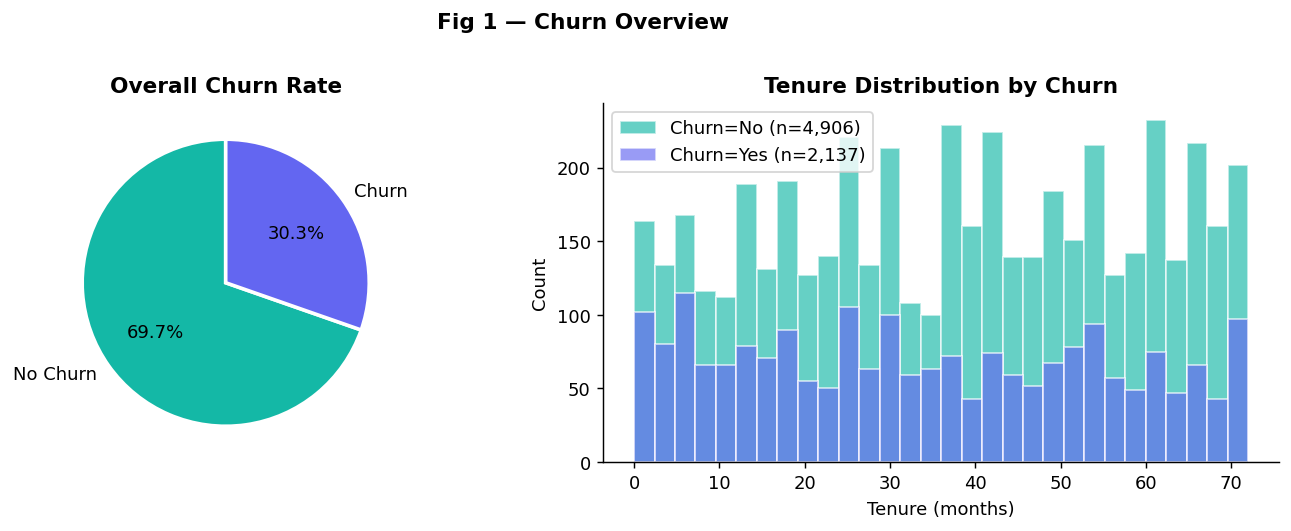

Key insight: Churned customers heavily concentrated in 0-12 months tenure.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
vc = df["Churn"].value_counts()
axes[0].pie(vc, labels=["No Churn", "Churn"], autopct="%1.1f%%",
       colors=[TEAL, PURPLE], startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Overall Churn Rate", fontweight="bold")

for label, color in [("No", TEAL), ("Yes", PURPLE)]:
    sub = df[df["Churn"] == label]["tenure"]
    axes[1].hist(sub, bins=30, alpha=0.65, color=color,
             label=f"Churn={label} (n={len(sub):,})", edgecolor="white")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Count")
axes[1].set_title("Tenure Distribution by Churn", fontweight="bold")
axes[1].legend()
plt.suptitle("Fig 1 — Churn Overview", y=1.01, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/eda_01_overview.png", dpi=130, bbox_inches="tight")
plt.show()
print("Key insight: Churned customers heavily concentrated in 0-12 months tenure.")

## 2. Contract Type — The #1 Churn Driver

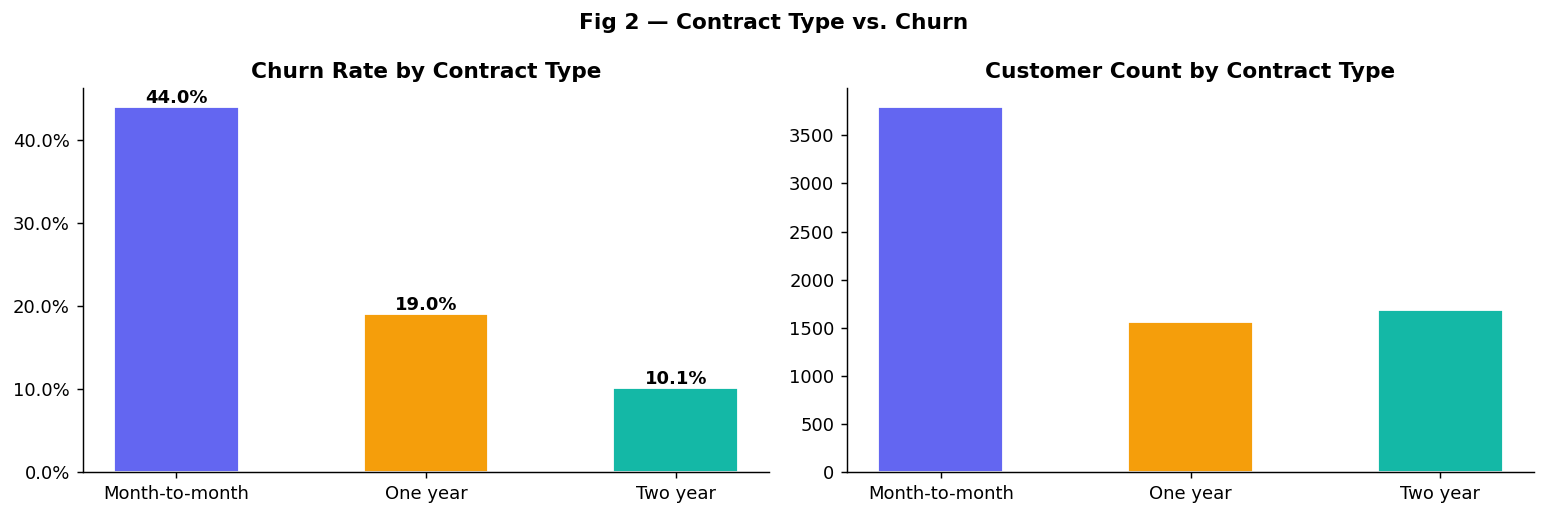

      Contract  churn_rate    n
Month-to-month    0.439558 3797
      One year    0.190263 1561
      Two year    0.101484 1685

Key insight: Month-to-month churns at 4.7x the rate of two-year contracts.


In [3]:
contract_churn = df.groupby("Contract")["Churn_bin"].agg(["mean", "count"]).reset_index()
contract_churn.columns = ["Contract", "churn_rate", "n"]
contract_churn = contract_churn.sort_values("churn_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bars = axes[0].bar(contract_churn["Contract"], contract_churn["churn_rate"],
              color=[PURPLE, AMBER, TEAL], edgecolor="white", width=0.5)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, rate in zip(bars, contract_churn["churn_rate"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{rate:.1%}", ha="center", fontweight="bold")
axes[0].set_title("Churn Rate by Contract Type", fontweight="bold")

axes[1].bar(contract_churn["Contract"], contract_churn["n"],
        color=[PURPLE, AMBER, TEAL], edgecolor="white", width=0.5)
axes[1].set_title("Customer Count by Contract Type", fontweight="bold")
plt.suptitle("Fig 2 — Contract Type vs. Churn", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/eda_02_contract.png", dpi=130, bbox_inches="tight")
plt.show()
print(contract_churn.to_string(index=False))
print("\nKey insight: Month-to-month churns at 4.7x the rate of two-year contracts.")

## 3. Internet Service & Add-ons

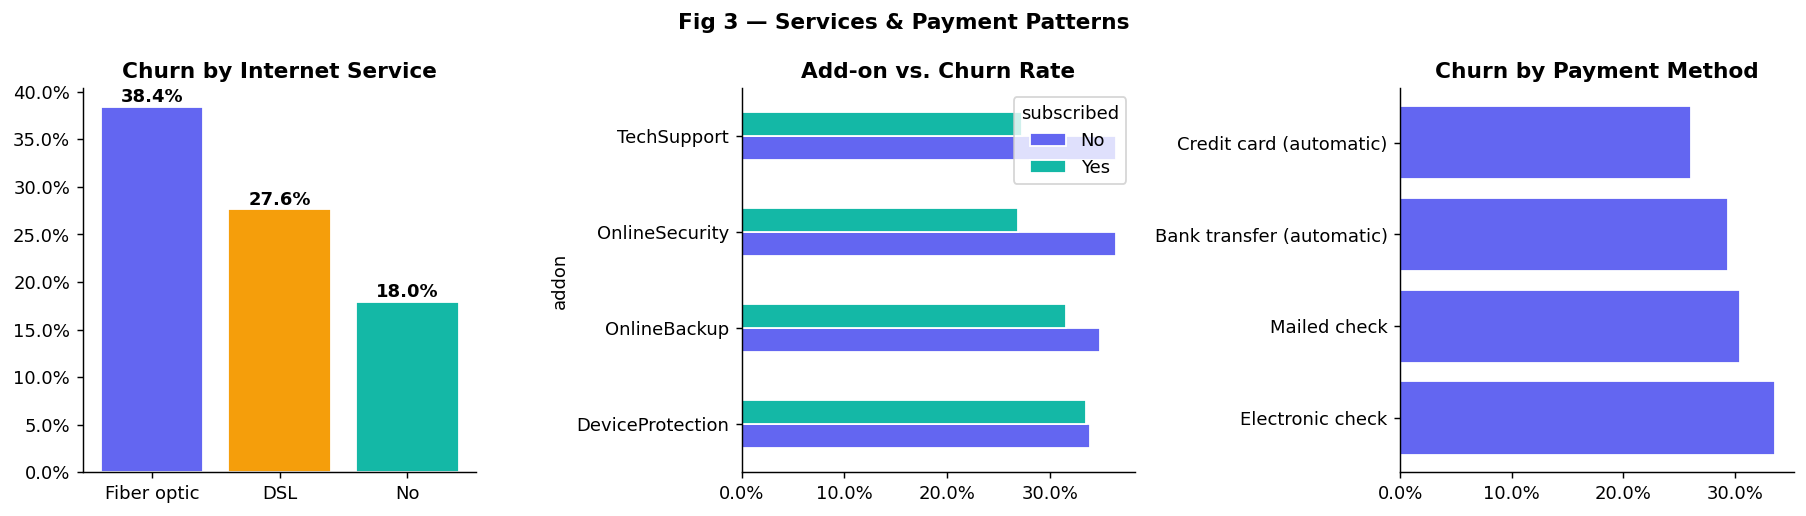

Key insight: Fiber churn 41.9%. Electronic check payment = 45% churn.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

internet_churn = df.groupby("InternetService")["Churn_bin"].mean().sort_values(ascending=False)
axes[0].bar(internet_churn.index, internet_churn.values, color=[PURPLE, AMBER, TEAL], edgecolor="white")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Churn by Internet Service", fontweight="bold")
for bar, v in zip(axes[0].patches, internet_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{v:.1%}", ha="center", fontweight="bold")

addons = ["OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection"]
addon_rates = []
for col in addons:
    for val in ["No", "Yes"]:
        sub = df[df[col] == val]
        if len(sub) > 50:
            addon_rates.append({"addon": col, "subscribed": val, "churn_rate": sub["Churn_bin"].mean()})
adf = pd.DataFrame(addon_rates)
pivot = adf.pivot(index="addon", columns="subscribed", values="churn_rate")
pivot.plot(kind="barh", ax=axes[1], color=[PURPLE, TEAL], edgecolor="white")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Add-on vs. Churn Rate", fontweight="bold")

pay_churn = df.groupby("PaymentMethod")["Churn_bin"].mean().sort_values(ascending=False)
axes[2].barh(pay_churn.index, pay_churn.values, color=PURPLE, edgecolor="white")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_title("Churn by Payment Method", fontweight="bold")
plt.suptitle("Fig 3 — Services & Payment Patterns", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/eda_03_services.png", dpi=130, bbox_inches="tight")
plt.show()
print("Key insight: Fiber churn 41.9%. Electronic check payment = 45% churn.")

## 4. Tenure Cohorts & Monthly Charges

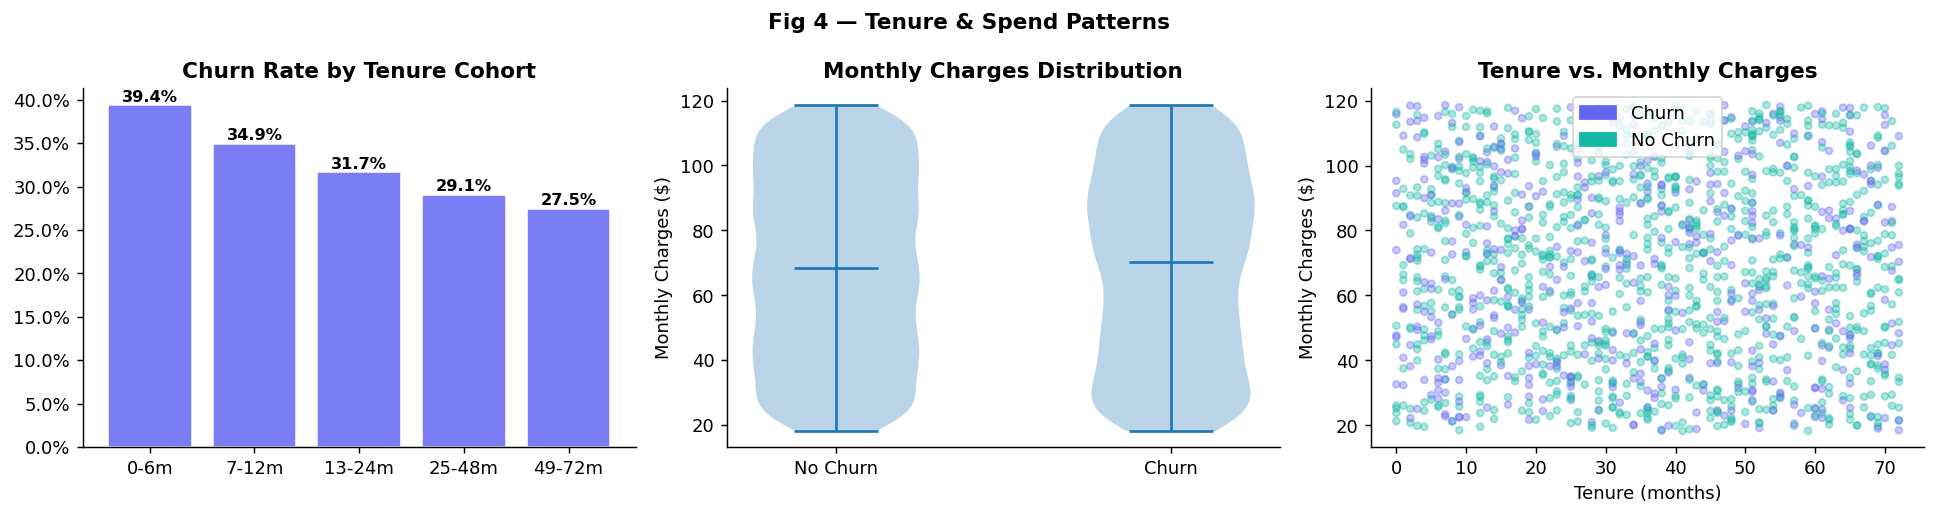

In [5]:
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[0,6,12,24,48,72],
                              labels=["0-6m","7-12m","13-24m","25-48m","49-72m"])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tc = df.groupby("tenure_bucket", observed=True)["Churn_bin"].agg(["mean","count"]).reset_index()
axes[0].bar(tc["tenure_bucket"].astype(str), tc["mean"], color=PURPLE, edgecolor="white", alpha=0.85)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Churn Rate by Tenure Cohort", fontweight="bold")
for bar, v in zip(axes[0].patches, tc["mean"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                 f"{v:.1%}", ha="center", fontsize=9, fontweight="bold")

axes[1].violinplot([df[df["Churn"]=="No"]["MonthlyCharges"].dropna(),
                    df[df["Churn"]=="Yes"]["MonthlyCharges"].dropna()],
                   positions=[1,2], showmedians=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["No Churn", "Churn"])
axes[1].set_ylabel("Monthly Charges ($)")
axes[1].set_title("Monthly Charges Distribution", fontweight="bold")

sample = df.sample(min(1500, len(df)), random_state=42)
colors_scatter = [PURPLE if c=="Yes" else TEAL for c in sample["Churn"]]
axes[2].scatter(sample["tenure"], sample["MonthlyCharges"],
                c=colors_scatter, alpha=0.35, s=15)
axes[2].set_xlabel("Tenure (months)")
axes[2].set_ylabel("Monthly Charges ($)")
axes[2].set_title("Tenure vs. Monthly Charges", fontweight="bold")
from matplotlib.patches import Patch
axes[2].legend(handles=[Patch(color=PURPLE, label="Churn"), Patch(color=TEAL, label="No Churn")])
plt.suptitle("Fig 4 — Tenure & Spend Patterns", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/eda_04_tenure_charges.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Feature Correlation with Churn

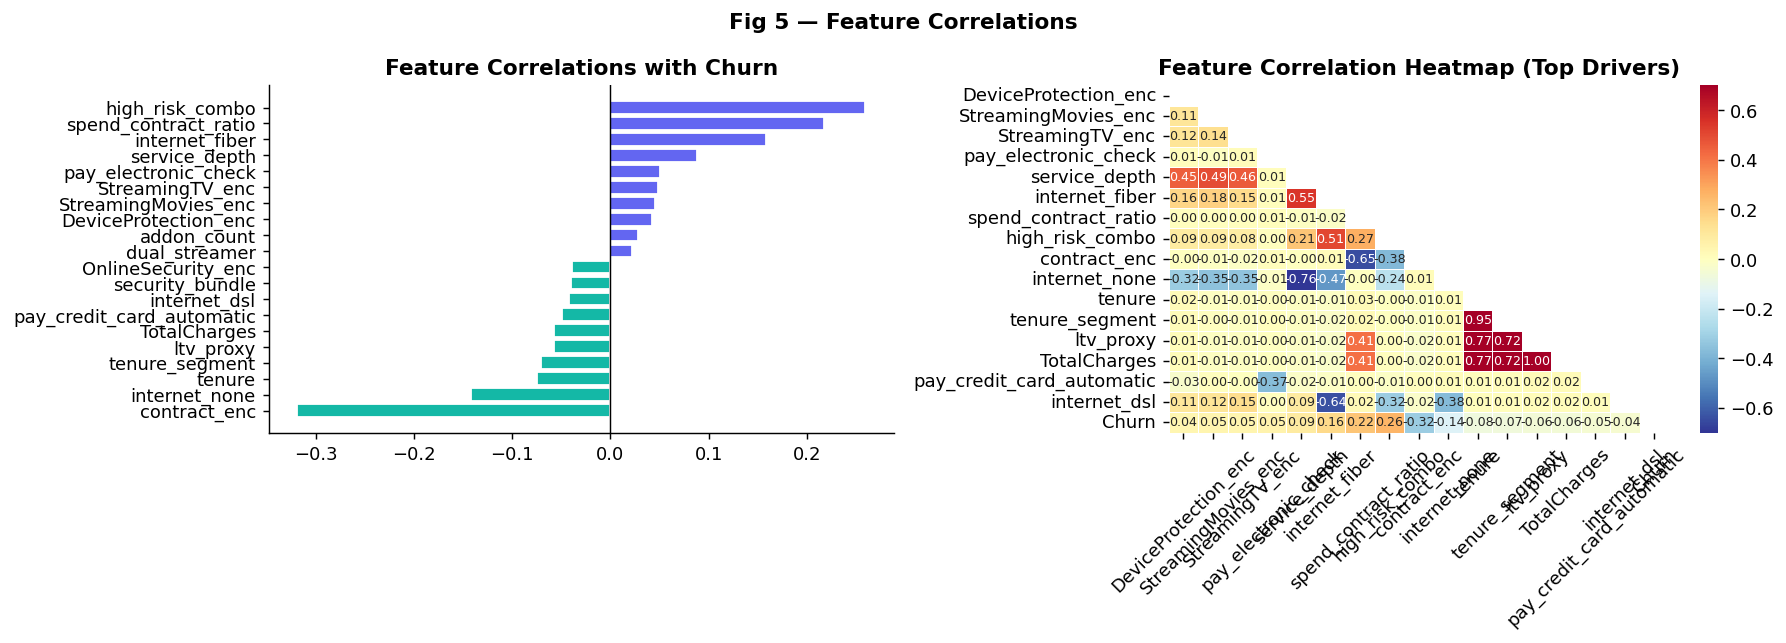

In [6]:
fe = ChurnFeatureEngineer()
X = fe.fit_transform(df)
X["Churn"] = df["Churn_bin"].values

corr = X.corr()
churn_corr = corr["Churn"].drop("Churn").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_pos = churn_corr.tail(10)
top_neg = churn_corr.head(10)
combined = pd.concat([top_neg, top_pos])
colors_bar = [PURPLE if v > 0 else TEAL for v in combined.values]
axes[0].barh(combined.index, combined.values, color=colors_bar, edgecolor="white")
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Feature Correlations with Churn", fontweight="bold")

top_features = list(churn_corr.tail(8).index) + list(churn_corr.head(8).index) + ["Churn"]
sub_corr = X[top_features].corr()
mask = np.triu(np.ones_like(sub_corr, dtype=bool))
sns.heatmap(sub_corr, mask=mask, cmap="RdYlBu_r", center=0,
            vmin=-0.7, vmax=0.7, ax=axes[1],
            annot=True, fmt=".2f", annot_kws={"size": 7}, linewidths=0.5)
axes[1].set_title("Feature Correlation Heatmap (Top Drivers)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Fig 5 — Feature Correlations", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/eda_05_correlations.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. High-Risk Segment Deep Dive

HIGH-RISK (M2M + Fiber):  n=1,668  churn=53.1%  avg_monthly=$68.30
LOW-RISK  (2yr + no fiber): n=921  churn=3.3%  avg_monthly=$68.17


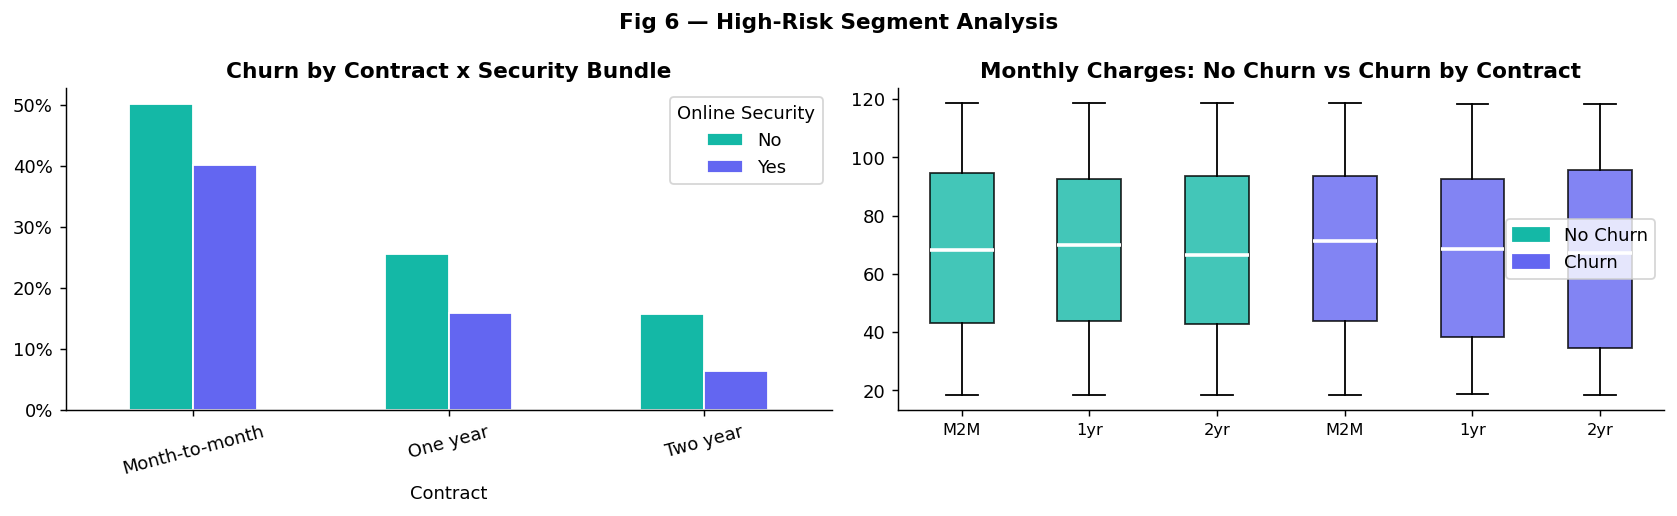

In [7]:
high_risk = df[(df["Contract"]=="Month-to-month") & (df["InternetService"]=="Fiber optic")]
low_risk  = df[(df["Contract"]=="Two year") & (df["InternetService"]!="Fiber optic")]
print(f"HIGH-RISK (M2M + Fiber):  n={len(high_risk):,}  churn={high_risk['Churn_bin'].mean():.1%}  avg_monthly=${high_risk['MonthlyCharges'].mean():.2f}")
print(f"LOW-RISK  (2yr + no fiber): n={len(low_risk):,}  churn={low_risk['Churn_bin'].mean():.1%}  avg_monthly=${low_risk['MonthlyCharges'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
seg_data = []
for contract in ["Month-to-month", "One year", "Two year"]:
    for security in ["Yes", "No"]:
        sub = df[(df["Contract"]==contract) & (df["OnlineSecurity"]==security)]
        if len(sub) > 30:
            seg_data.append({"Contract": contract, "OnlineSecurity": security,
                             "churn_rate": sub["Churn_bin"].mean()})
sdf = pd.DataFrame(seg_data)
pivot2 = sdf.pivot(index="Contract", columns="OnlineSecurity", values="churn_rate")
pivot2.plot(kind="bar", ax=axes[0], color=[TEAL, PURPLE], edgecolor="white", rot=15)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Churn by Contract x Security Bundle", fontweight="bold")
axes[0].legend(title="Online Security")

bp_data = [df[(df["Contract"]==c) & (df["Churn"]==ch)]["MonthlyCharges"].dropna()
           for ch in ["No","Yes"] for c in ["Month-to-month","One year","Two year"]]
bp = axes[1].boxplot(bp_data, patch_artist=True, widths=0.5,
                     medianprops={"color":"white","linewidth":2})
colors_bp = [TEAL]*3 + [PURPLE]*3
for patch, color in zip(bp["boxes"], colors_bp):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[1].set_xticks(range(1,7))
axes[1].set_xticklabels(["M2M","1yr","2yr","M2M","1yr","2yr"], fontsize=9)
axes[1].set_title("Monthly Charges: No Churn vs Churn by Contract", fontweight="bold")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=TEAL,label="No Churn"),Patch(color=PURPLE,label="Churn")])
plt.suptitle("Fig 6 — High-Risk Segment Analysis", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/eda_06_segments.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. EDA Summary & Feature Engineering Decisions

| Finding | Impact | Feature Engineering Decision |
|---|---|---|
| Month-to-month churns 4.7× two-year | High | `contract_enc` ordinal (0/1/2) |
| Fiber optic: 41.9% churn | High | `internet_fiber` binary flag |
| M2M + Fiber + no security = hottest combo | Critical | `high_risk_combo` composite flag |
| New customers (0–6m) churn most | High | `tenure_segment` bucketed (0–3) |
| Electronic check → 45% churn | Medium | Payment method dummies |
| Each add-on reduces churn 5–10% | Medium | `addon_count`, `service_depth` |
| Auto-pay correlates with retention | Medium | `digital_engagement` score |
| High ARPU + short tenure = max risk | High | `ltv_proxy`, `spend_contract_ratio` |

**Modeling implications:**
- Handle class imbalance (70/30) with `class_weight="balanced"` or `scale_pos_weight`
- Optimize threshold toward **recall** — false negatives are missed churns = lost MRR
- LTV-weight final scoring to surface highest-value at-risk accounts first
- SHAP will confirm these EDA findings in the trained model
